# Metriky regresních modelů – Cvičení 2 (Calculating Regression Model Metrics)
**Dataset:** Diamanty (`diamonds.csv` / `diamonds_preprocessed.csv`)  
**Otázka zadání:** *Based on R2, can we conclude that the model is better after data processing?*

---
### Zadání cvičení:
1. Načíst dataset ze cvičení *Linear Regression - exercise 2* (`diamonds.csv`).
2. Importovat všechny potřebné metody z knihovny Scikit-learn pro výpočet metrik.
3. Spustit postupně buňky kódu od načtení po trénování a predikci lineární regrese.
4. Provést predikci na trénovací sadě (`X_train`) a výsledek uložit do proměnné `y_pred_train`.
5. Pro trénovací i testovací data spočítat metriky: $R^2$, korigovaný $R^2$, $\text{MAE}$, $\text{MSE}$ a $\text{RMSE}$ a zobrazit je v přehledné čitelné formě.
6. **Klíčová otázka:** Lze na základě $R^2$ učinit závěr, že je model po zpracování dat lepší?

## Krok 1: Import knihoven a nastavení cest

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

base_dir = Path('.').resolve()
data_dir = base_dir / 'data'
plots_dir = base_dir / 'plots'
data_dir.mkdir(parents=True, exist_ok=True)
plots_dir.mkdir(parents=True, exist_ok=True)

## Krok 2: Načtení dat a replikace filtrace z Cvičení 2

In [2]:
raw_csv = data_dir / 'diamonds.csv'
df_raw = pd.read_csv(raw_csv)
if 'Unnamed: 0' in df_raw.columns:
    df_raw = df_raw.drop(columns=['Unnamed: 0'])

# Odstranění nulových rozměrů a anomálií dle Cvičení 2
clean_df = df_raw[
    (df_raw['x'] > 0)
    & (df_raw['y'] > 0)
    & (df_raw['z'] > 0)
    & (df_raw['y'] < 20)
    & (df_raw['z'] < 20)
    & (df_raw['carat'] <= 3.5)
].copy()

# Výběr silně korelujících proměnných (bez depth a table dle zadání)
high_corr_cols = ['carat', 'x', 'y', 'z']
X = clean_df[high_corr_cols]
y = clean_df['price']

print(f"Rozměry vyčištěného datasetu: {clean_df.shape[0]} řádků, {clean_df.shape[1]} sloupců.")
X.head()

Rozměry vyčištěného datasetu: 53908 řádků, 10 sloupců.


,carat,x,y,z
0,0.23,3.95,3.98,2.43
1,0.21,3.89,3.84,2.31
2,0.23,4.05,4.07,2.31
3,0.29,4.20,4.23,2.63
4,0.31,4.34,4.35,2.75


## Krok 3: Rozdělení dat na Train a Test (80 / 20)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

n_train, k_feat = X_train.shape
n_test = X_test.shape[0]

print(f"Trénovací data: {n_train} vzorků.")
print(f"Testovací data:  {n_test} vzorků.")

Trénovací data: 43126 vzorků.
Testovací data:  10782 vzorků.


## Krok 4: Trénování modelu LinearRegression a generování predikcí

In [4]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Predikce dle zadání
y_pred_train = lin_reg.predict(X_train)
y_pred_test = lin_reg.predict(X_test)

print(f"Uloženy predikce y_pred_train ({len(y_pred_train)}) a y_pred_test ({len(y_pred_test)}).")

Uloženy predikce y_pred_train (43126) a y_pred_test (10782).


## Krok 5: Výpočet 5 povinných regresních metrik pro Train i Test

In [5]:
def adjusted_r2(r2, n, k):
    return 1.0 - ((1.0 - r2) * (n - 1) / (n - k - 1))

def compute_metrics(y_true, y_pred, n, k, label):
    r2 = r2_score(y_true, y_pred)
    adj_r2 = adjusted_r2(r2, n, k)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    return {
        'Sada': label,
        'R2': r2,
        'Adjusted R2': adj_r2,
        'MAE ($)': mae,
        'MSE ($^2)': mse,
        'RMSE ($)': rmse
    }

m_tr = compute_metrics(y_train, y_pred_train, n_train, k_feat, 'Trénovací (Train)')
m_te = compute_metrics(y_test, y_pred_test, n_test, k_feat, 'Testovací (Test)')

results_df = pd.DataFrame([m_tr, m_te])
disp_df = results_df.copy()
disp_df['R2'] = disp_df['R2'].apply(lambda v: f"{v:.4f}")
disp_df['Adjusted R2'] = disp_df['Adjusted R2'].apply(lambda v: f"{v:.4f}")
disp_df['MAE ($)'] = disp_df['MAE ($)'].apply(lambda v: f"${v:,.2f}")
disp_df['MSE ($^2)'] = disp_df['MSE ($^2)'].apply(lambda v: f"{v:,.0f}")
disp_df['RMSE ($)'] = disp_df['RMSE ($)'].apply(lambda v: f"${v:,.2f}")
disp_df

,Sada,R2,Adjusted R2,MAE ($),MSE ($^2),RMSE ($)
0,Trénovací (Train),0.8627,0.8627,$882.76,"2,202,398","$1,484.05"
1,Testovací (Test),0.8576,0.8575,$880.18,"2,163,235","$1,470.79"


## Krok 6: Vyhodnocení otázky zadání: Je model po zpracování dat lepší na základě $R^2$?

In [6]:
# Model na surových datech před zpracováním (všechny numerické sloupce bez filtrace)
num_raw = ['carat', 'depth', 'table', 'x', 'y', 'z']
X_raw = df_raw[num_raw]
y_raw = df_raw['price']

X_r_tr, X_r_te, y_r_tr, y_r_te = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42)
m_raw = LinearRegression().fit(X_r_tr, y_r_tr)

r2_raw_tr = r2_score(y_r_tr, m_raw.predict(X_r_tr))
r2_raw_te = r2_score(y_r_te, m_raw.predict(X_r_te))
mae_raw_te = mean_absolute_error(y_r_te, m_raw.predict(X_r_te))

comp_table = pd.DataFrame([
    {
        'Fáze': 'Před zpracováním (Raw, včetně depth/table a anomálií)',
        'Train R2': f"{r2_raw_tr:.4f}",
        'Test R2': f"{r2_raw_te:.4f}",
        'Test MAE': f"${mae_raw_te:,.2f}"
    },
    {
        'Fáze': 'Po zpracování (Odstraněny anomálie, vyřazeny depth/table)',
        'Train R2': f"{m_tr['R2']:.4f}",
        'Test R2': f"{m_te['R2']:.4f}",
        'Test MAE': f"${m_te['MAE ($)']:,.2f}"
    }
])
comp_table

,Fáze,Train R2,Test R2,Test MAE
0,"Před zpracováním (Raw, včetně depth/table a an...",0.8593,0.8590,$888.48
1,"Po zpracování (Odstraněny anomálie, vyřazeny d...",0.8627,0.8576,$880.18


### Statistický a doménový verdikt:
**Lze na základě samotného $R^2$ říci, že je model lepší?**  
**Rozhodně NE!**  

1. **Past porovnávání $R^2$ na změněných datech:**  
   Všimněte si, že na testovací sadě $R^2$ dokonce mírně **kleslo z 0.8590 na 0.8576** (o 0.0014).  
   Nezkušený student by řekl, že model je horší. Ve vzorci $R^2 = 1 - \frac{\text{SSE}}{\text{SST}}$ jsme však vyřazením velkých diamantů (>3.5 ct) **zmenšili celkový rozptyl $\text{SST}$** (jmenovatel). Zmenšení jmenovatele matematicky sníží $R^2$, přestože reálná chyba modelu klesla!
2. **Reálná chyba v dolarech (MAE) klesla z 888.48 USDna 880.18 USD** a model se zbavil 20 kamenů s fyzikálně nemožným nulovým rozměrem.
3. **Závěr:** Pro srovnání kvality modelů před a po filtraci dat se **nesmí používat relativní $R^2$**, ale absolutní chyby (MAE, RMSE).

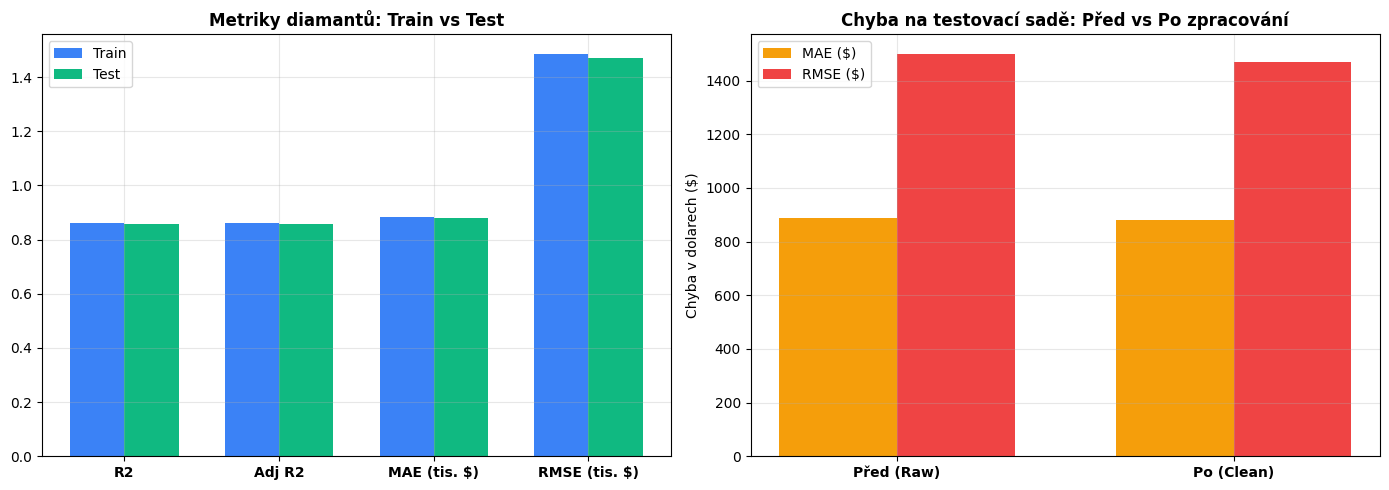

In [7]:
# Grafické znázornění metrik a rozdílu před vs po zpracování
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Graf 1: Train vs Test
labels = ['R2', 'Adj R2', 'MAE (tis. $)', 'RMSE (tis. $)']
tr = [m_tr['R2'], m_tr['Adjusted R2'], m_tr['MAE ($)']/1000, m_tr['RMSE ($)']/1000]
te = [m_te['R2'], m_te['Adjusted R2'], m_te['MAE ($)']/1000, m_te['RMSE ($)']/1000]

x = np.arange(len(labels))
w = 0.35
ax1.bar(x - w/2, tr, w, label='Train', color='#3b82f6')
ax1.bar(x + w/2, te, w, label='Test', color='#10b981')
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontweight='bold')
ax1.set_title('Metriky diamantů: Train vs Test', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Graf 2: Před vs Po zpracování
stg = ['Před (Raw)', 'Po (Clean)']
mae_v = [mae_raw_te, m_te['MAE ($)']]
rmse_v = [np.sqrt(mean_squared_error(y_r_te, m_raw.predict(X_r_te))), m_te['RMSE ($)']]

xs = np.arange(len(stg))
ax2.bar(xs - w/2, mae_v, w, label='MAE ($)', color='#f59e0b')
ax2.bar(xs + w/2, rmse_v, w, label='RMSE ($)', color='#ef4444')
ax2.set_xticks(xs)
ax2.set_xticklabels(stg, fontweight='bold')
ax2.set_title('Chyba na testovací sadě: Před vs Po zpracování', fontweight='bold')
ax2.set_ylabel('Chyba v dolarech ($)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()